# 商品期货 Alpha 研究工作流

## 与股票研究的关键差异

| 模块 | 股票 | 商品期货 | 是否兼容 |
|------|------|----------|----------|
| **Alpha158 特征** | 基于 OHLCV 技术指标 | 基于 OHLCV 技术指标 | ✅ 完全兼容 |
| **数据管道 (AlphaLab)** | 从 parquet 文件读取 | 从 parquet 文件读取 | ✅ 完全兼容 |
| **LGB / MLP 模型** | 通用回归 | 通用回归 | ✅ 完全兼容 |
| **成分股过滤** | 沪深300等指数成分 | 无此概念，跳过 | ⚠️ 期货不需要 |
| **回测引擎 (alpha.strategy)** | 股票多头 + 等权分配 | 缺少乘数/保证金/双向仓位 | ❌ 不兼容 |

**期货回测**：使用 `vnpy_ctastrategy.backtesting.BacktestingEngine`，不使用 `vnpy.alpha.strategy.BacktestingEngine`。

**数据**：使用 RQData 主力连续合约（`get_dominant_price`，前复权），规避换月跳空问题。

# 一、准备数据

In [11]:
# 加载模块
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import polars as pl

from vnpy.trader.constant import Interval, Exchange
from vnpy.alpha import AlphaLab

In [12]:
# 创建数据中心（指定期货专用目录）
lab: AlphaLab = AlphaLab("./lab/futures")

In [13]:
# 设置任务参数
name = "futures_lgb"
start: str = "2015-01-01"
end: str = "2024-12-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

# 商品期货品种篮子（主力连续合约，使用 88 后缀 vnpy 标准惯例）
# RqdataDatafeed 对 88 后缀合约自动使用前复权（adjust_type="pre"）
# 格式：(symbol, exchange)
FUTURES_BASKET: list[tuple[str, Exchange]] = [
    # 黑色系
    ("rb88", Exchange.SHFE),   # 螺纹钢
    ("hc88", Exchange.SHFE),   # 热轧卷板
    ("i88",  Exchange.DCE),    # 铁矿石
    ("j88",  Exchange.DCE),    # 焦炭
    ("jm88", Exchange.DCE),    # 焦煤
    # 有色金属
    ("cu88", Exchange.SHFE),   # 铜
    ("al88", Exchange.SHFE),   # 铝
    ("zn88", Exchange.SHFE),   # 锌
    ("ni88", Exchange.SHFE),   # 镍
    # 贵金属
    ("au88", Exchange.SHFE),   # 黄金
    ("ag88", Exchange.SHFE),   # 白银
    # 能化
    ("ru88", Exchange.SHFE),   # 橡胶
    ("sc88", Exchange.INE),    # 原油（2018年上市）
    ("TA88", Exchange.CZCE),   # PTA
    ("pp88", Exchange.DCE),    # 聚丙烯
    # 农产品
    ("m88",  Exchange.DCE),    # 豆粕
    ("y88",  Exchange.DCE),    # 豆油
    ("p88",  Exchange.DCE),    # 棕榈油
    ("c88",  Exchange.DCE),    # 玉米
    ("a88",  Exchange.DCE),    # 大豆
    ("SR88", Exchange.CZCE),   # 白糖
    ("CF88", Exchange.CZCE),   # 棉花
]

# 生成 vt_symbol 列表
futures_symbols: list[str] = [f"{symbol}.{exchange.value}" for symbol, exchange in FUTURES_BASKET]
print(f"品种数量: {len(futures_symbols)}")
print(futures_symbols)

品种数量: 22
['rb88.SHFE', 'hc88.SHFE', 'i88.DCE', 'j88.DCE', 'jm88.DCE', 'cu88.SHFE', 'al88.SHFE', 'zn88.SHFE', 'ni88.SHFE', 'au88.SHFE', 'ag88.SHFE', 'ru88.SHFE', 'sc88.INE', 'TA88.CZCE', 'pp88.DCE', 'm88.DCE', 'y88.DCE', 'p88.DCE', 'c88.DCE', 'a88.DCE', 'SR88.CZCE', 'CF88.CZCE']


In [14]:
# 从 AKShare 下载主力合约日线数据并保存到 AlphaLab
# 使用 futures_zh_daily_sina：列名已为英文，历史数据更长（2009年起）
# 注意：新浪财经主力数据为合约拼接，未做价格复权，换月时可能存在跳空
import akshare as ak
from datetime import datetime

from vnpy.trader.object import BarData
from vnpy.trader.utility import ZoneInfo

CHINA_TZ = ZoneInfo("Asia/Shanghai")

# vnpy 88后缀 → AKShare Sina 主力合约代码（0后缀，大写）
# 完整列表见：ak.futures_display_main_sina()
SINA_SYMBOL_MAP: dict[str, str] = {
    "rb88": "RB0",  "hc88": "HC0",  "i88":  "I0",   "j88":  "J0",   "jm88": "JM0",
    "cu88": "CU0",  "al88": "AL0",  "zn88": "ZN0",  "ni88": "NI0",
    "au88": "AU0",  "ag88": "AG0",
    "ru88": "RU0",  "sc88": "SC0",  "TA88": "TA0",  "pp88": "PP0",
    "m88":  "M0",   "y88":  "Y0",   "p88":  "P0",
    "c88":  "C0",   "a88":  "A0",   "SR88": "SR0",  "CF88": "CF0",
}

for symbol, exchange in FUTURES_BASKET:
    sina_symbol = SINA_SYMBOL_MAP[symbol]
    try:
        # 返回列：date(str "YYYY-MM-DD"), open, high, low, close, volume, hold(持仓量), settle
        df = ak.futures_zh_daily_sina(symbol=sina_symbol)
    except Exception as e:
        print(f"{symbol}: 下载失败 - {e}")
        continue

    if df is None or df.empty:
        print(f"{symbol}: 无数据")
        continue

    # date 列为字符串 "YYYY-MM-DD"，字符串比较等价于日期比较
    df["date"] = df["date"].astype(str)
    df = df[(df["date"] >= start) & (df["date"] <= end)]

    if df.empty:
        print(f"{symbol}: 日期范围内无数据")
        continue

    bars: list[BarData] = []
    for row in df.itertuples(index=False):
        dt = datetime.strptime(row.date, "%Y-%m-%d").replace(tzinfo=CHINA_TZ)
        bar = BarData(
            symbol=symbol,
            exchange=exchange,
            datetime=dt,
            interval=Interval.DAILY,
            open_price=float(row.open),
            high_price=float(row.high),
            low_price=float(row.low),
            close_price=float(row.close),
            volume=float(row.volume),
            turnover=float(row.close) * float(row.volume),  # 新浪无成交额，用收盘价×成交量代替
            open_interest=float(row.hold),
            gateway_name="AK"
        )
        bars.append(bar)

    lab.save_bar_data(bars)
    print(f"{symbol}.{exchange.value}: {len(bars)} bars saved")

rb88.SHFE: 2432 bars saved
hc88.SHFE: 2433 bars saved
i88.DCE: 2433 bars saved
j88.DCE: 2431 bars saved
jm88.DCE: 2430 bars saved
cu88.SHFE: 2432 bars saved
al88.SHFE: 2432 bars saved
zn88.SHFE: 2432 bars saved
ni88.SHFE: 2378 bars saved
au88.SHFE: 2433 bars saved
ag88.SHFE: 2432 bars saved
ru88.SHFE: 2434 bars saved
sc88.INE: 1644 bars saved
TA88.CZCE: 2428 bars saved
pp88.DCE: 2432 bars saved
m88.DCE: 2433 bars saved
y88.DCE: 2431 bars saved
p88.DCE: 2428 bars saved
c88.DCE: 2432 bars saved
a88.DCE: 2431 bars saved
SR88.CZCE: 2429 bars saved
CF88.CZCE: 2428 bars saved


In [15]:
# 加载并检验数据
df: pl.DataFrame = lab.load_bar_df(futures_symbols, interval, start, end, extended_days)
print(df.shape)


(52648, 10)


# 二、特征计算

Alpha158 特征全部基于 OHLCV 数据（价格动量、成交量相关性、统计特征），对商品期货**完全兼容**。

期货无成分股概念，`prepare_data(filters=None)` 跳过成分股过滤，对所有品种全周期使用数据。

In [16]:
# 加载模块
from functools import partial

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_cs_norm
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [17]:
# 创建数据集对象
# 期货样本量较少，适当缩短训练/验证周期
dataset: AlphaDataset = Alpha158(
    df,
    train_period = ("2015-01-01", "2020-12-31"),
    valid_period = ("2021-01-01", "2022-12-31"),
    test_period  = ("2023-01-01", "2024-12-31"),
)

In [18]:
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))

In [19]:
# 准备特征和标签数据（filters=None 跳过成分股过滤）
# 注意：Jupyter 在 Windows 上 multiprocessing spawn 会重入 notebook 导致错误
# 使用 max_workers=1 在单进程内安全运行（速度稍慢但稳定）
dataset.prepare_data(filters=None, max_workers=1)

2026-03-01 22:42:52 开始计算表达式因子特征


  0%|          | 0/159 [00:00<?, ?it/s]

Feature calculation kmid took: 0.001066446304321289 seconds | (close - open) / open
Feature calculation klen took: 0.0008602142333984375 seconds | (high - low) / open
Feature calculation kmid_2 took: 0.0010287761688232422 seconds | (close - open) / (high - low + 1e-12)
Feature calculation kup took: 0.010207176208496094 seconds | (high - ts_greater(open, close)) / open
Feature calculation kup_2 took: 0.007999420166015625 seconds | (high - ts_greater(open, close)) / (high - low + 1e-12)
Feature calculation klow took: 0.006000518798828125 seconds | (ts_less(open, close) - low) / open
Feature calculation klow_2 took: 0.006129741668701172 seconds | ((ts_less(open, close) - low) / (high - low + 1e-12))
Feature calculation ksft took: 0.0010347366333007812 seconds | (close * 2 - high - low) / open
Feature calculation ksft_2 took: 0.000978231430053711 seconds | (close * 2 - high - low) / (high - low + 1e-12)
Feature calculation open_0 took: 0.0010223388671875 seconds | open / close
Feature calc

 12%|█▏        | 19/159 [00:01<00:10, 13.74it/s]

Feature calculation ma_5 took: 1.333770513534546 seconds | ts_mean(close, 5) / close
Feature calculation ma_10 took: 1.3950040340423584 seconds | ts_mean(close, 10) / close


...

 94%|█████████▎| 149/159 [02:06<00:11,  1.11s/it]

Feature calculation wvma_60 took: 4.593821048736572 seconds | ts_std(ts_abs(close / ts_delay(close, 1) - 1) * volume, 60) / (ts_mean(ts_abs(close / ts_delay(close, 1) - 1) * volume, 60) + 1e-12)
Feature calculation vsump_5 took: 0.02581310272216797 seconds | ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), 5) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), 5) + 1e-12)
Feature calculation vsump_10 took: 0.019647836685180664 seconds | ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), 10) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), 10) + 1e-12)
Feature calculation vsump_20 took: 0.01712512969970703 seconds | ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), 20) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), 20) + 1e-12)
Feature calculation vsump_30 took: 0.014062643051147461 seconds | ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), 30) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), 30) + 1e-12)
Feature calculation vsump_60 took: 0.016312360763549805 seconds | ts_sum(ts_gr

100%|██████████| 159/159 [02:06<00:00,  1.26it/s]

Feature calculation vsumd_5 took: 0.037192344665527344 seconds | (ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), 5) - ts_sum(ts_greater(ts_delay(volume, 1) - volume, 0), 5)) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), 5) + 1e-12)
Feature calculation vsumd_10 took: 0.02492070198059082 seconds | (ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), 10) - ts_sum(ts_greater(ts_delay(volume, 1) - volume, 0), 10)) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), 10) + 1e-12)
Feature calculation vsumd_20 took: 0.02551436424255371 seconds | (ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), 20) - ts_sum(ts_greater(ts_delay(volume, 1) - volume, 0), 20)) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), 20) + 1e-12)
Feature calculation vsumd_30 took: 0.024442434310913086 seconds | (ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), 30) - ts_sum(ts_greater(ts_delay(volume, 1) - volume, 0), 30)) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), 30) + 1e-12)
Feature calculation vsumd_60 took:


0it [00:00, ?it/s]


Dropped 0.5% entries from factor data: 0.4% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.000000,3.679229e+17,3.871992e+13,3.393214e+15,12048,22.989295
2.0,0.097610,8.985553e+16,4.587881e+13,1.728307e+15,9681,18.472723
3.0,0.139825,2.594878e+17,1.423918e+14,4.834543e+15,9680,18.470815
4.0,0.158825,3.679229e+17,2.057665e+14,7.174597e+15,9681,18.472723
5.0,0.184184,1.236383e+18,5.050210e+14,1.701664e+16,11317,21.594443


Returns Analysis


,1D,5D,10D
Ann. alpha,-0.051,-0.051,-0.038
beta,-0.067,-0.107,-0.126
Mean Period Wise Return Top Quantile (bps),-2.990,-2.709,-1.859
Mean Period Wise Return Bottom Quantile (bps),2.349,2.566,2.176
Mean Period Wise Spread (bps),-5.339,-5.287,-4.037


<Figure size 640x480 with 0 Axes>

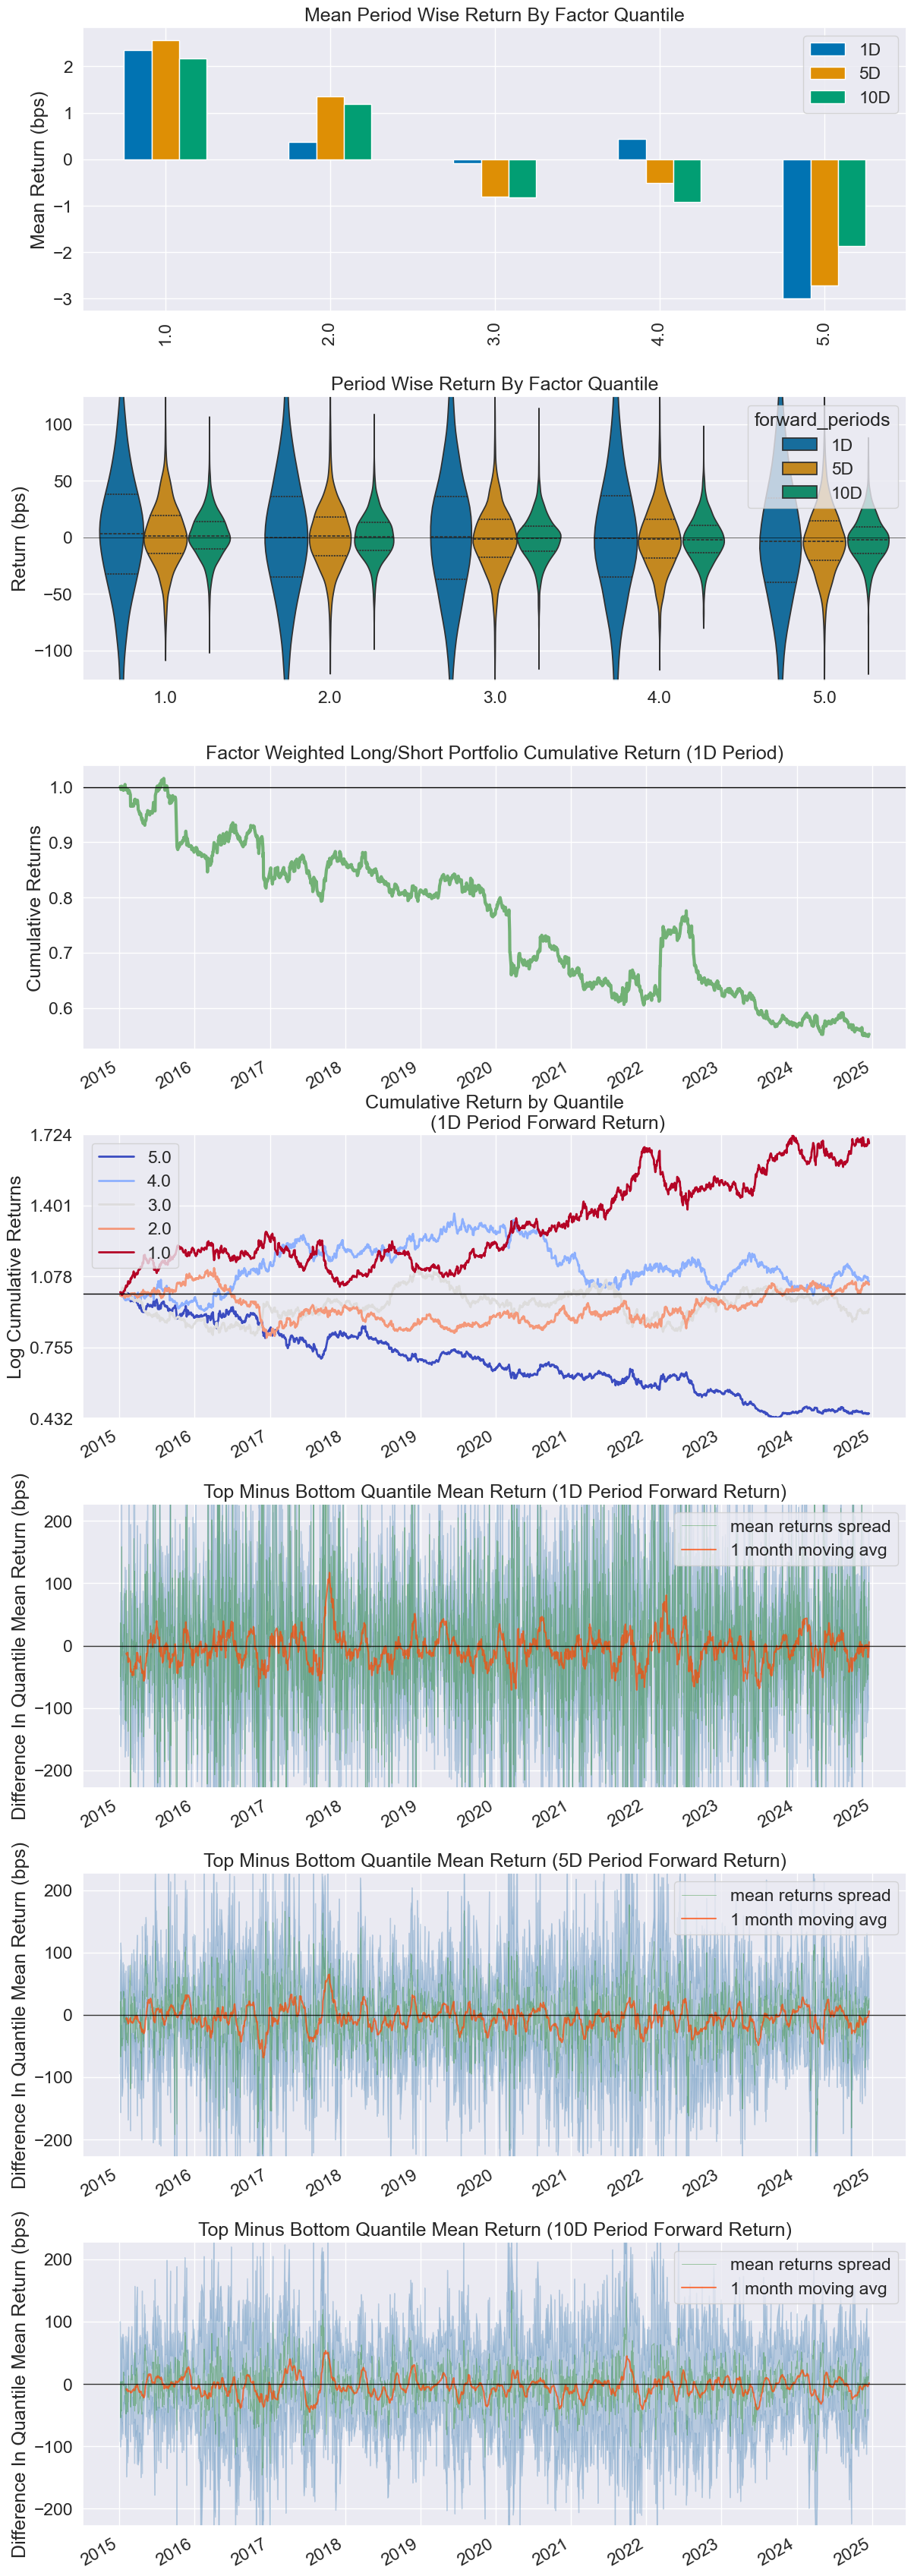

C:\Users\ericf\AppData\Roaming\Python\Python311\site-packages\alphalens\performance.py:57: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda x: stats.spearmanr(x, f)[0]


Information Analysis


,1D,5D,10D
IC Mean,-0.012,-0.027,-0.035
IC Std.,0.264,0.269,0.266
Risk-Adjusted IC,-0.046,-0.101,-0.130
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


C:\Users\ericf\AppData\Roaming\Python\Python311\site-packages\alphalens\performance.py:57: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda x: stats.spearmanr(x, f)[0]


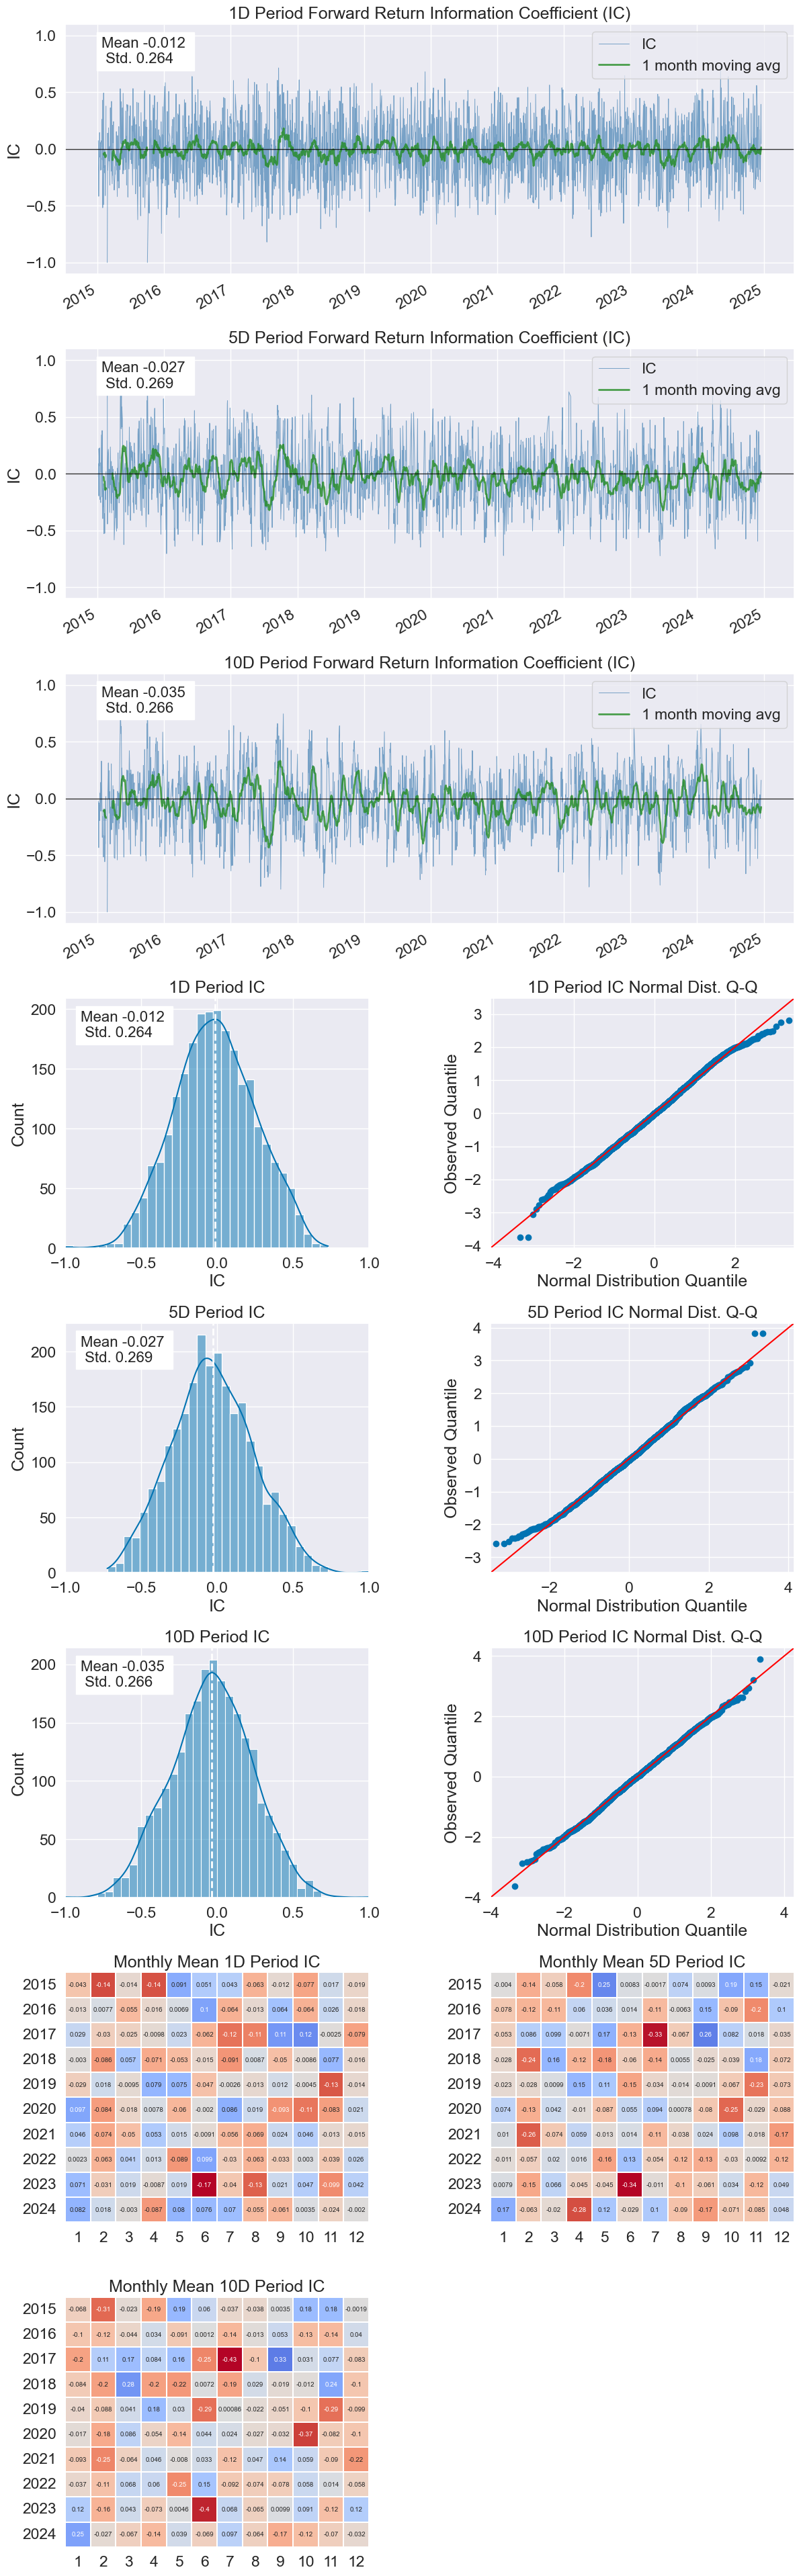

C:\Users\ericf\AppData\Roaming\Python\Python311\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.407,0.526,0.616
Quantile 2.0 Mean Turnover,0.696,0.759,0.784
Quantile 3.0 Mean Turnover,0.707,0.772,0.794
Quantile 4.0 Mean Turnover,0.671,0.749,0.776
Quantile 5.0 Mean Turnover,0.388,0.534,0.641


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.689,0.476,0.315


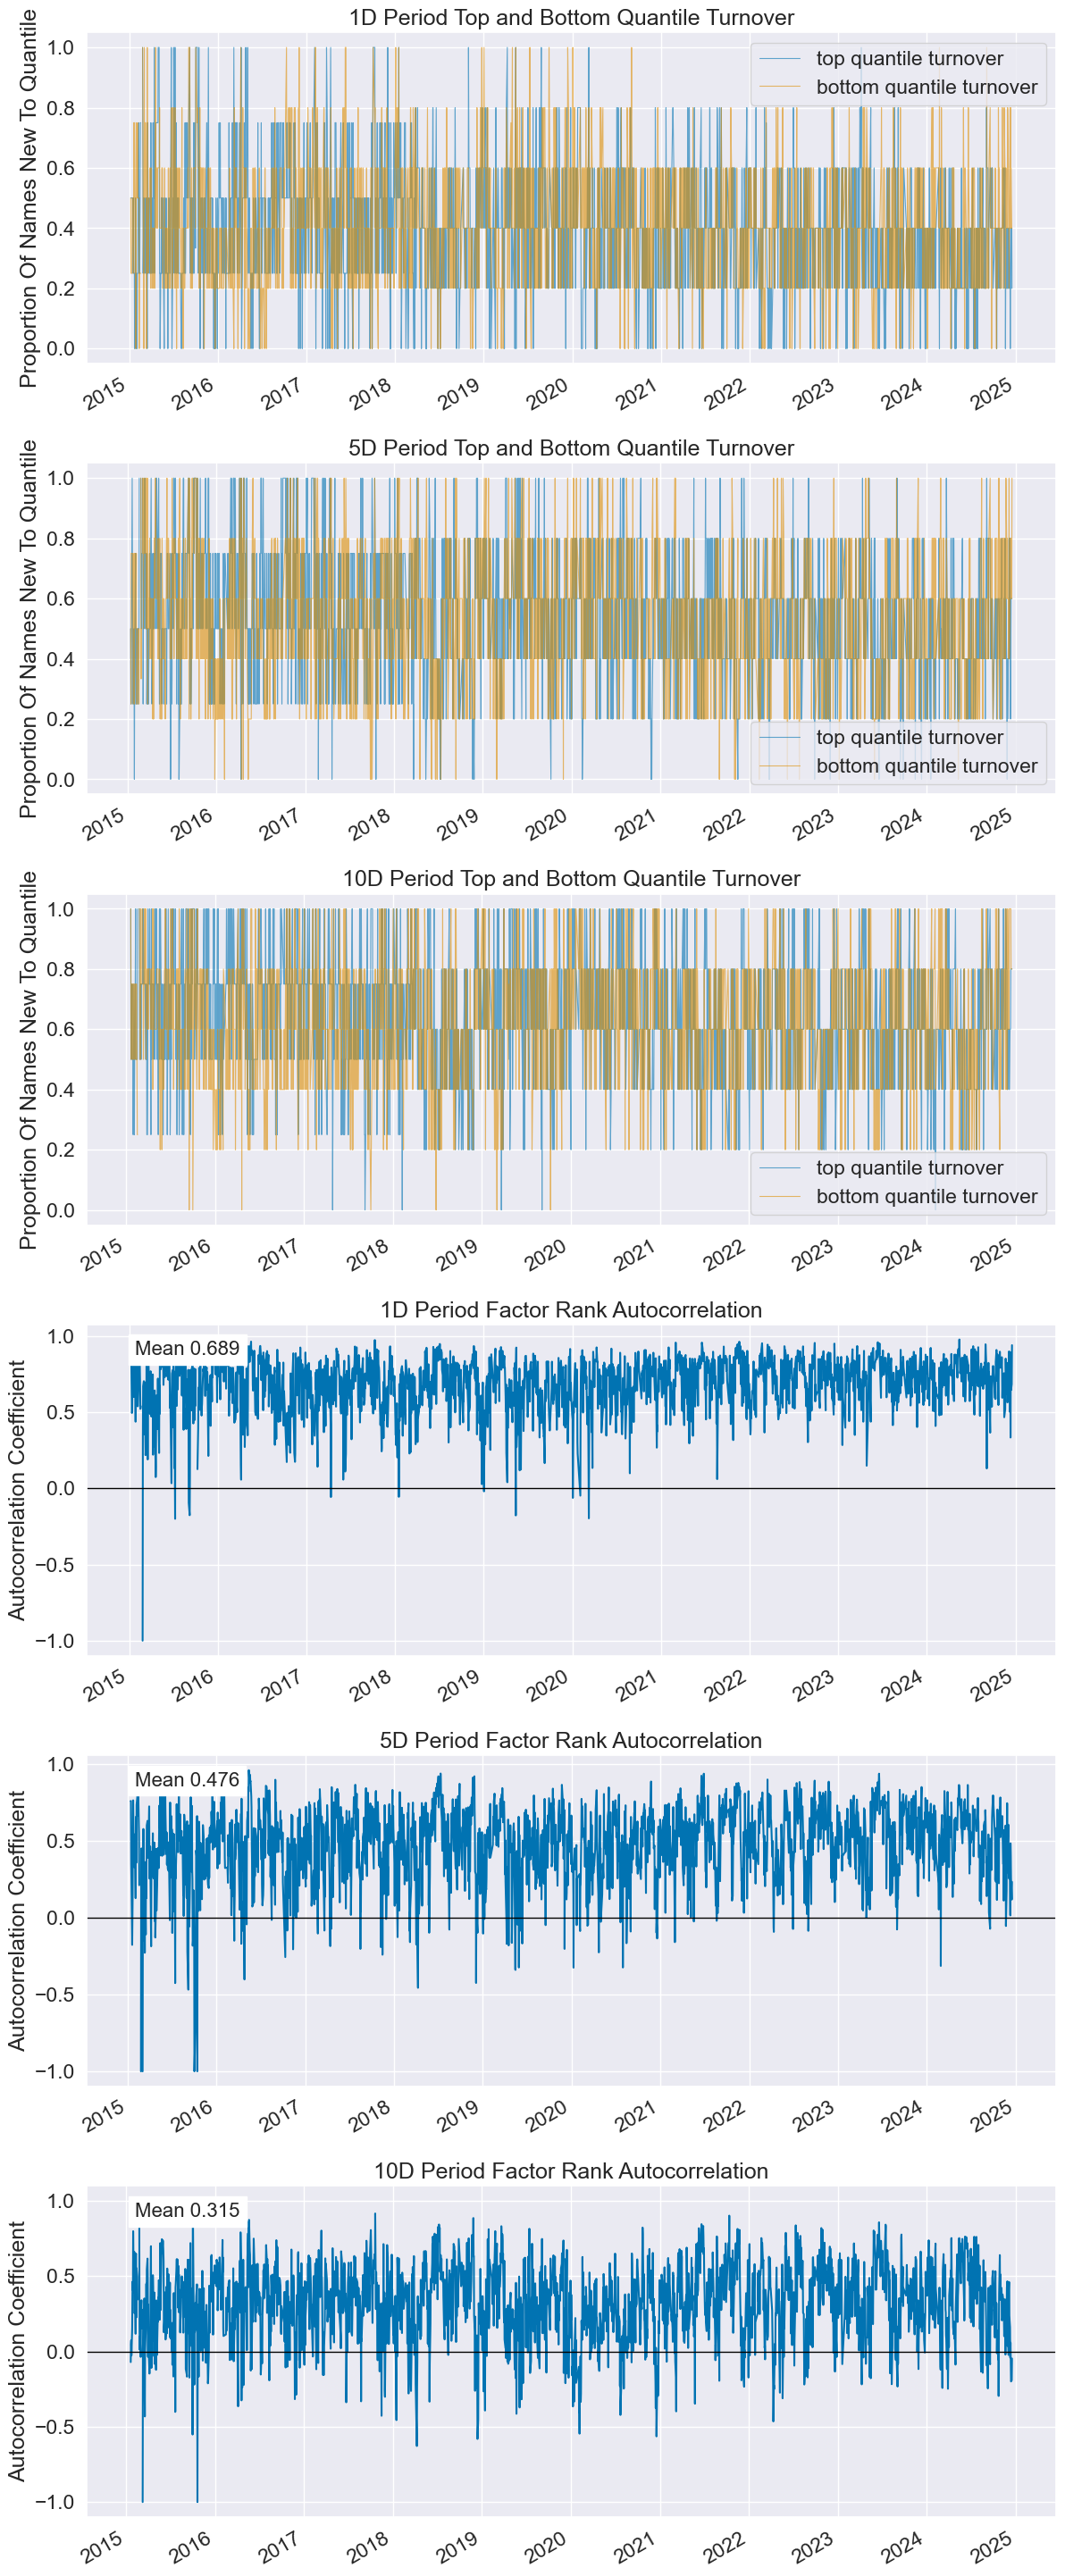

In [20]:
# 查看单个特征绩效（以 vstd_20 为例）
dataset.show_feature_performance("vstd_20")

In [11]:
# 数据预处理
dataset.process_data()

In [12]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 三、模型训练

In [14]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel
from vnpy.alpha.model.models.lgb_model import LgbModel

In [15]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [16]:
# 创建并训练模型
model: AlphaModel = LgbModel(seed=42)
model.fit(dataset)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31958
[LightGBM] [Info] Number of data points in the train set: 31333, number of used features: 158
[LightGBM] [Info] Start training from score -0.000000
[1]	train's l2: 0.948385	valid's l2: 0.95491
Training until validation scores don't improve for 50 rounds
[2]	train's l2: 0.94338	valid's l2: 0.954915
[3]	train's l2: 0.939288	valid's l2: 0.955214
[4]	train's l2: 0.935196	valid's l2: 0.95515
[5]	train's l2: 0.931307	valid's l2: 0.955345
[6]	train's l2: 0.927904	valid's l2: 0.955627
[7]	train's l2: 0.924266	valid's l2: 0.955874
[8]	train's l2: 0.920767	valid's l2: 0.95602
[9]	train's l2: 0.917356	valid's l2: 0.956028
[10]	train's l2: 0.913423	valid's l2: 0.956313
[11]	train's l2: 0.910184	valid's l2: 0.956677
[12]	train's l2: 0.907195	valid's l2: 0.956832
[13]	train's l2: 0.904147	valid's l2: 0.957

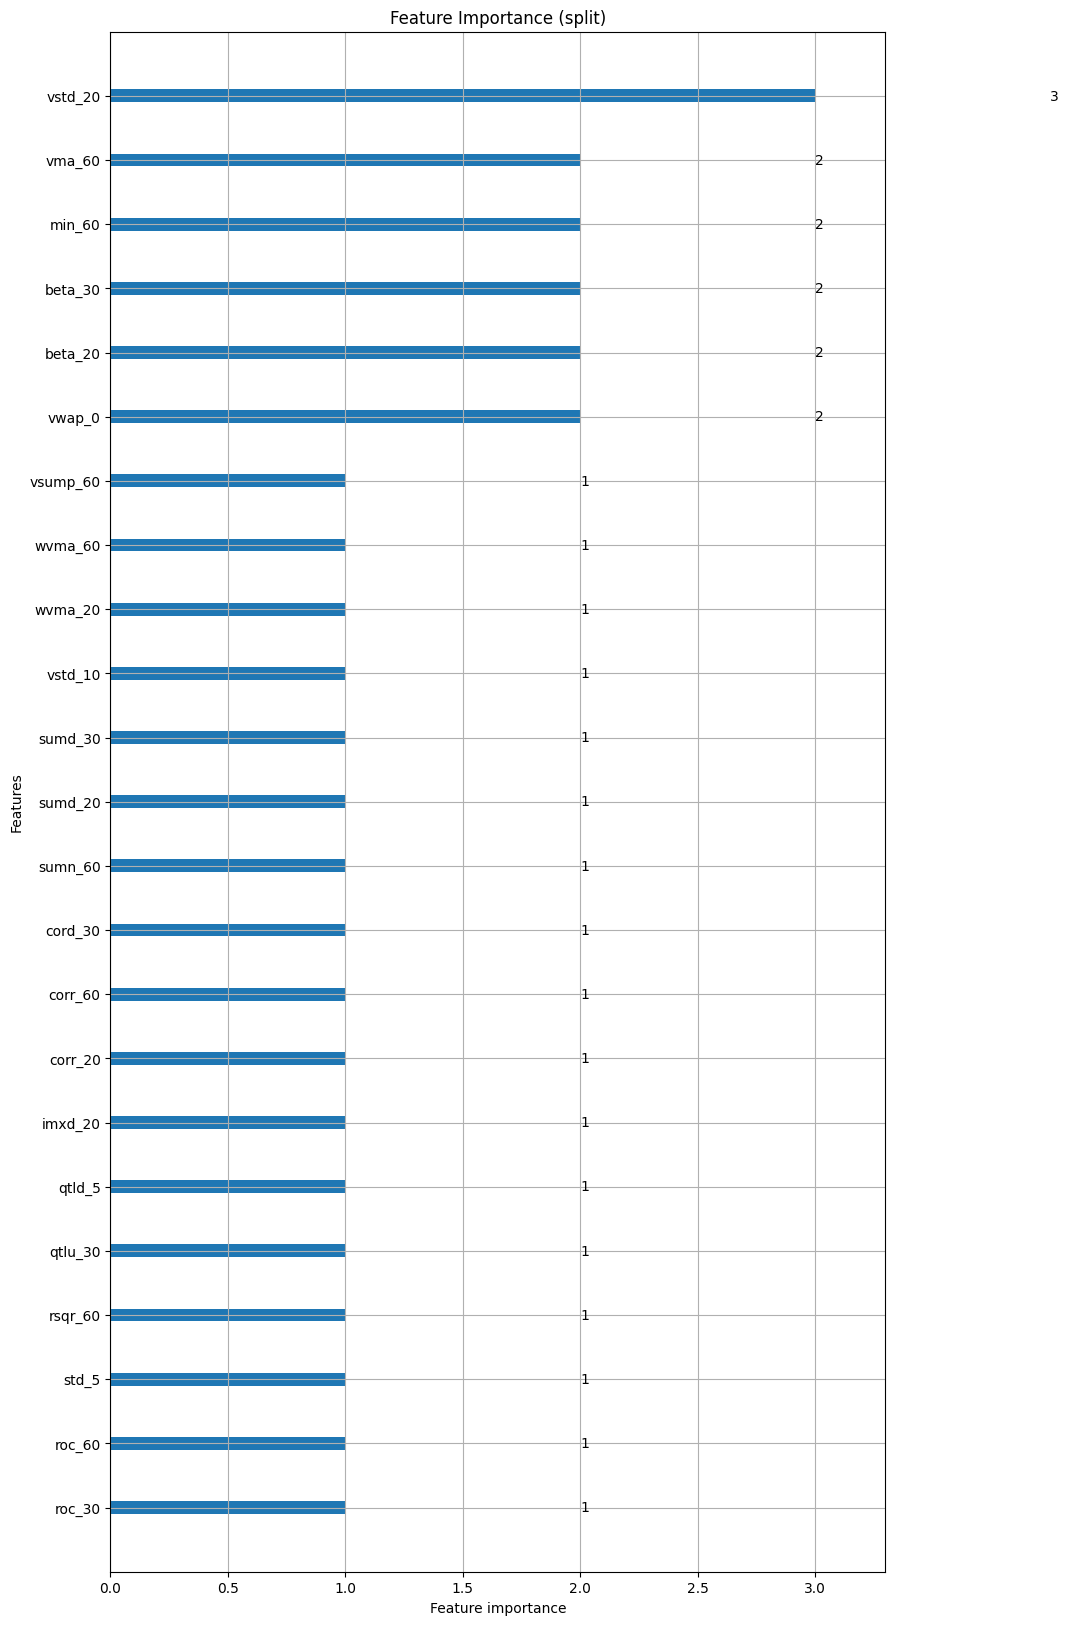

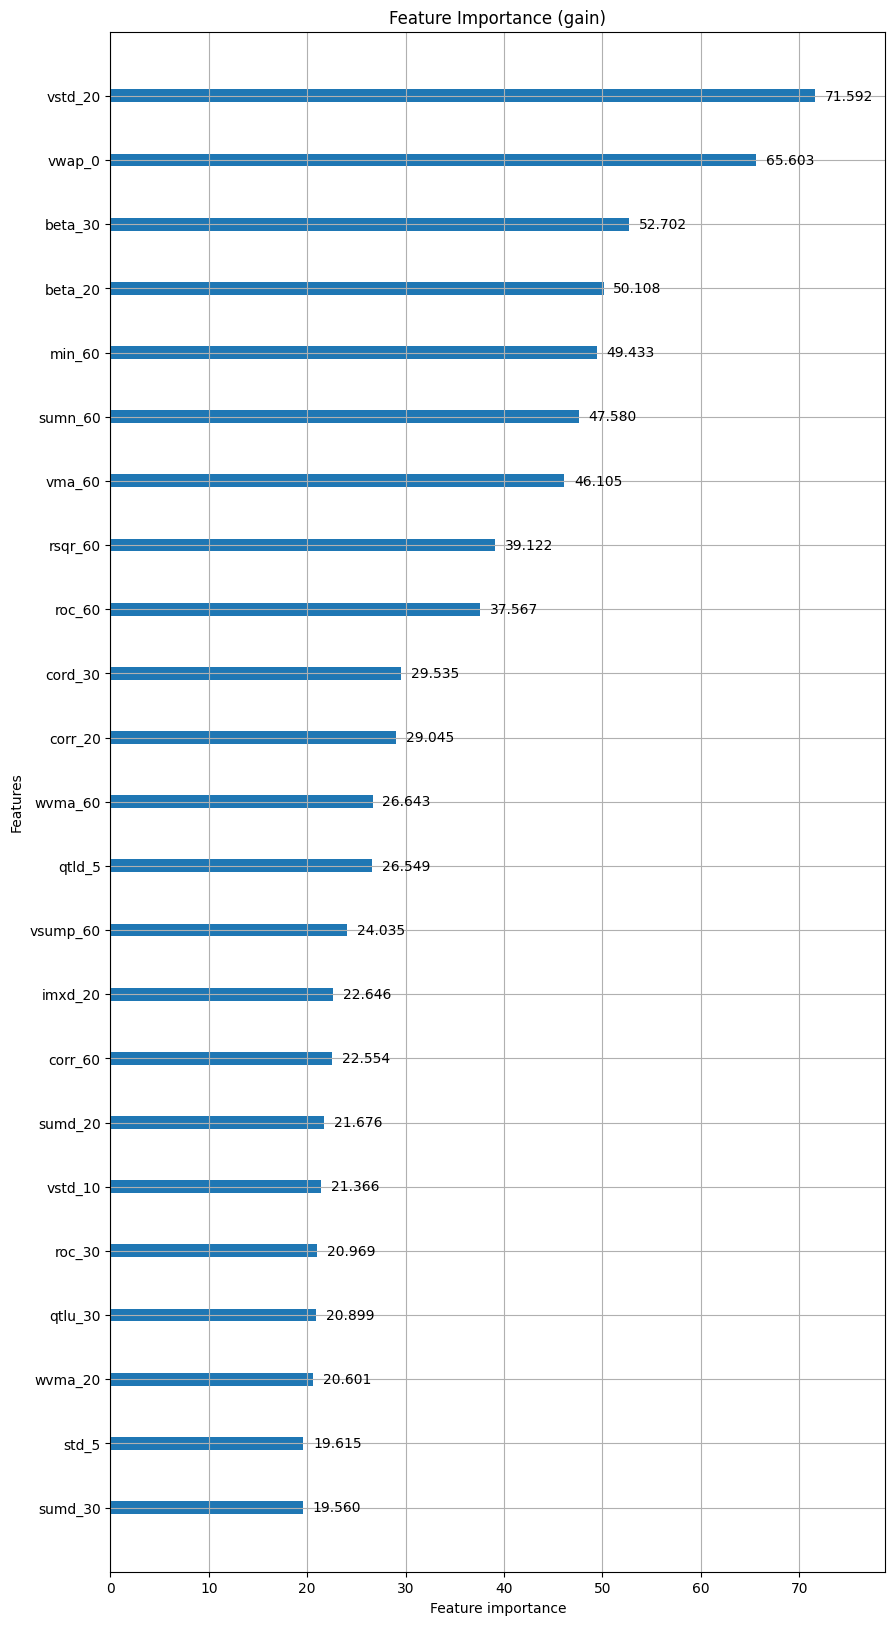

In [17]:
# 查看特征重要性
model.detail()

In [18]:
# 保存模型
lab.save_model(name, model)

# 四、预测信号

In [19]:
model: AlphaModel = lab.load_model(name)

# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]
signal

datetime,vt_symbol,signal
datetime[μs],str,f64
2023-01-03 00:00:00,"""CF88.CZCE""",-0.001651
2023-01-03 00:00:00,"""SR88.CZCE""",-0.001651
2023-01-03 00:00:00,"""TA88.CZCE""",0.005395
2023-01-03 00:00:00,"""a88.DCE""",-0.005951
2023-01-03 00:00:00,"""ag88.SHFE""",-0.173173
…,…,…
2024-12-31 00:00:00,"""rb88.SHFE""",-0.001651
2024-12-31 00:00:00,"""ru88.SHFE""",-0.001651
2024-12-31 00:00:00,"""sc88.INE""",0.005395


In [20]:
# 检查信号绩效（Alphalens 因子分析）
dataset.show_signal_performance(signal)

Dropped 100.0% entries from factor data: 2.1% in forward returns computation and 97.9% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,


ValueError: No objects to concatenate

<Figure size 640x480 with 0 Axes>

In [ ]:
# 保存信号数据
lab.save_signal(name, signal)

# 五、策略绩效评估（全面回测报告）

本节对信号驱动的等权多空组合进行全面评估，覆盖以下维度：

| 维度 | 指标 |
|------|------|
| **收益** | 总收益、CAGR、年化波动率 |
| **风险调整** | Sharpe（无风险利率 2.5%）、Sortino、Calmar |
| **回撤** | 最大回撤、最大回撤持续天数、最长恢复时间 |
| **交易统计** | 胜率、盈利因子、期望收益 |
| **图表** | 净值+回撤曲线、月度热力图、滚动 Sharpe、收益分布 |
| **异常值分析** | 移除最佳/最差 N 天后策略是否仍盈利 |
| **蒙特卡洛** | 5000 次重采样，盈利概率、最坏情况回撤 |
| **统计显著性** | t 检验、Bootstrap Sharpe 置信区间 |

> **说明**：此处采用等权信号多空组合（不含合约乘数），用于快速验证信号方向有效性。
> 完整期货回测需使用 `vnpy_ctastrategy.backtesting.BacktestingEngine`（含乘数/保证金）。
> 年交易日取 **242**（中国期货市场），无风险利率取 **2.5%**（2024 年 SHIBOR 约 2.5%）。

In [ ]:

# ============================================================
# Cell 1/4: 数据准备 + 全面绩效指标
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# 中文字体（Windows）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---- 参数 ----
PERIODS_PER_YEAR = 242   # 中国期货市场年交易日
RISK_FREE_RATE   = 0.025 # 年化无风险利率（SHIBOR 约 2.5%）
rf_daily = RISK_FREE_RATE / PERIODS_PER_YEAR

# ---- 数据准备 ----
signal = lab.load_signal(name)

df_raw = lab.load_bar_df(futures_symbols, interval, "2023-01-01", end, extended_days=0)

df_ret = (
    df_raw
    .sort(["vt_symbol", "datetime"])
    .with_columns(
        (pl.col("close").shift(-1).over("vt_symbol") / pl.col("close") - 1).alias("next_ret")
    )
)

df_eval = (
    signal
    .join(df_ret.select(["datetime", "vt_symbol", "next_ret"]), on=["datetime", "vt_symbol"], how="left")
    .with_columns(
        (pl.col("signal").sign() * pl.col("next_ret")).alias("strategy_ret")
    )
)

# 日度等权组合收益
daily_ret_pl = (
    df_eval
    .group_by("datetime")
    .agg(pl.col("strategy_ret").mean())
    .sort("datetime")
    .drop_nulls()
)

# 转换为 pandas Series（带 DatetimeIndex）
returns = pd.Series(
    daily_ret_pl["strategy_ret"].to_list(),
    index=pd.to_datetime(daily_ret_pl["datetime"].to_list()),
    name="strategy"
).dropna()

# ---- 回撤序列 ----
cumret = (1 + returns).cumprod()
rolling_max = cumret.expanding().max()
drawdown = (cumret / rolling_max) - 1

# ---- 指标计算 ----
# 收益
total_ret = (1 + returns).prod() - 1
years = len(returns) / PERIODS_PER_YEAR
cagr = (1 + total_ret) ** (1 / years) - 1
ann_vol = returns.std() * np.sqrt(PERIODS_PER_YEAR)

# 风险调整收益
excess = returns - rf_daily
sharpe = float(np.sqrt(PERIODS_PER_YEAR) * excess.mean() / excess.std())

downside = returns[returns < rf_daily]
downside_std = downside.std() * np.sqrt(PERIODS_PER_YEAR) if len(downside) > 0 else np.nan
sortino = (cagr - RISK_FREE_RATE) / downside_std if (downside_std and downside_std > 0) else np.nan

max_dd = drawdown.min()
calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

# 回撤持续期
in_dd = False
dd_start = dd_trough = None
dd_trough_val = 0
dd_periods = []
for date, val in drawdown.items():
    if val < 0 and not in_dd:
        in_dd, dd_start, dd_trough_val, dd_trough = True, date, val, date
    elif val < dd_trough_val and in_dd:
        dd_trough_val, dd_trough = val, date
    elif val >= 0 and in_dd:
        in_dd = False
        dd_periods.append({
            'depth': dd_trough_val,
            'duration': (dd_trough - dd_start).days,
            'recovery': (date - dd_trough).days
        })
if in_dd:  # 仍处于回撤中
    dd_periods.append({'depth': dd_trough_val,
                       'duration': (dd_trough - dd_start).days,
                       'recovery': None})

max_dd_duration = max((d['duration'] for d in dd_periods), default=0)
recovery_vals = [d['recovery'] for d in dd_periods if d['recovery'] is not None]
max_recovery = max(recovery_vals) if recovery_vals else "未恢复"

# 交易统计（日度等权组合，每天视为一次交易）
wins   = returns[returns > 0]
losses = returns[returns < 0]
win_rate = len(wins) / len(returns)
avg_win  = wins.mean()  if len(wins)   > 0 else 0.0
avg_loss = abs(losses.mean()) if len(losses) > 0 else 0.0
profit_factor = wins.sum() / abs(losses.sum()) if len(losses) > 0 else np.inf
expectancy = win_rate * avg_win - (1 - win_rate) * avg_loss

# 连续盈亏
max_win_streak = max_loss_streak = streak = 0
prev_sign = None
for r in returns:
    cur = 1 if r > 0 else -1
    streak = streak + 1 if cur == prev_sign else 1
    if cur == 1:  max_win_streak  = max(max_win_streak,  streak)
    else:         max_loss_streak = max(max_loss_streak, streak)
    prev_sign = cur

# 统计检验
n = len(returns)
t_stat  = returns.mean() / (returns.std(ddof=1) / np.sqrt(n))
p_value = 1 - stats.t.cdf(t_stat, df=n - 1)

# ---- 打印绩效报告 ----
sep = "=" * 56
print(sep)
print("  期货 Alpha 策略绩效报告（等权信号多空，测试期）")
print(sep)

print(f"\n{'── 基础收益 ──'}")
print(f"  总收益率:              {total_ret:>9.2%}")
print(f"  年化收益 (CAGR):       {cagr:>9.2%}   基准 >15%")
print(f"  年化波动率:            {ann_vol:>9.2%}")

print(f"\n{'── 风险调整收益 ──'}")
print(f"  Sharpe Ratio:          {sharpe:>9.2f}   基准 >1.0  ({'✅' if sharpe > 1.0 else '⚠️'})")
print(f"  Sortino Ratio:         {sortino:>9.2f}   基准 >1.5  ({'✅' if isinstance(sortino, float) and sortino > 1.5 else '⚠️'})")
print(f"  Calmar Ratio:          {calmar:>9.2f}   基准 >1.0  ({'✅' if isinstance(calmar, float) and calmar > 1.0 else '⚠️'})")

print(f"\n{'── 回撤分析 ──'}")
print(f"  最大回撤:              {max_dd:>9.2%}   基准 <30%  ({'✅' if abs(max_dd) < 0.30 else '⚠️'})")
print(f"  最大回撤持续:          {max_dd_duration:>8}天")
print(f"  最长恢复时间:          {str(max_recovery)+'天':>9}")
print(f"  回撤次数:              {len(dd_periods):>9}")

print(f"\n{'── 交易统计（日度）──'}")
print(f"  总交易日:              {n:>9}")
print(f"  胜率:                  {win_rate:>9.2%}   基准 >45%  ({'✅' if win_rate > 0.45 else '⚠️'})")
print(f"  平均盈利日收益:        {avg_win:>9.4%}")
print(f"  平均亏损日收益:       -{avg_loss:>9.4%}")
print(f"  盈利因子:              {profit_factor:>9.2f}   基准 >1.5  ({'✅' if profit_factor > 1.5 else '⚠️'})")
print(f"  期望收益:              {expectancy:>9.5%}/日")
print(f"  最大连续盈利天数:      {max_win_streak:>9}")
print(f"  最大连续亏损天数:      {max_loss_streak:>9}")

print(f"\n{'── 统计显著性 ──'}")
print(f"  t 统计量:              {t_stat:>9.2f}   基准 >2.0  ({'✅' if t_stat > 2.0 else '⚠️'})")
print(f"  p 值（单侧）:          {p_value:>9.4f}   <0.05 显著 ({'✅' if p_value < 0.05 else '⚠️'})")
print(f"  样本量:                {n:>9}")
print(sep)


In [ ]:

# ============================================================
# Cell 2/4: 绩效图表（6张核心图）
# ============================================================

# --- 图表 1+2（上下拼接）：净值/回撤曲线 + 月度热力图 ---
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                 gridspec_kw={'height_ratios': [3, 1]})

# 净值曲线
ax1.plot(cumret.index, cumret.values, color='steelblue', linewidth=1.8, label='策略净值')
ax1.set_ylabel('净值', fontsize=11)
ax1.set_title('净值曲线（测试期 2023–2024）', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}x'))
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# 水下曲线（回撤）
ax2.fill_between(drawdown.index, drawdown.values, 0, color='crimson', alpha=0.4)
ax2.plot(drawdown.index, drawdown.values, color='crimson', linewidth=0.8)
ax2.set_ylabel('回撤', fontsize=11)
ax2.set_xlabel('日期', fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))
ax2.grid(True, alpha=0.3)
ax2.set_title('回撤（水下）曲线', fontsize=11)

fig1.tight_layout()
plt.savefig('./lab/futures/chart1_equity_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 图表 2：月度收益热力图 ---
monthly_rets = returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
mdf = pd.DataFrame({
    'year':  monthly_rets.index.year,
    'month': monthly_rets.index.month,
    'ret':   monthly_rets.values * 100
})
pivot = mdf.pivot(index='year', columns='month', values='ret')
pivot.columns = ['1月','2月','3月','4月','5月','6月',
                 '7月','8月','9月','10月','11月','12月']

fig2, ax = plt.subplots(figsize=(14, max(3, len(pivot) * 1.2)))
sns.heatmap(pivot, annot=True, fmt='.1f', center=0, cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': '月收益 (%)'}, annot_kws={'size': 10})
ax.set_title('月度收益热力图 (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('年份', fontsize=11)
fig2.tight_layout()
plt.savefig('./lab/futures/chart2_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 图表 3+4+5：滚动 Sharpe + 收益分布 + 年度收益 ---
fig3, axes = plt.subplots(1, 3, figsize=(18, 5))

# 滚动 Sharpe（60日窗口）
window = min(60, len(returns) // 4)
exc = returns - rf_daily
roll_sh = (exc.rolling(window).mean() / exc.rolling(window).std()) * np.sqrt(PERIODS_PER_YEAR)
ax3 = axes[0]
ax3.plot(roll_sh.index, roll_sh.values, color='steelblue', linewidth=1.3)
ax3.axhline(0,   color='black', linewidth=0.8, linestyle='--')
ax3.axhline(1.0, color='green', linewidth=0.8, linestyle=':', alpha=0.8, label='Sharpe=1.0')
ax3.fill_between(roll_sh.index, roll_sh.values, 0,
                 where=(roll_sh > 0), color='green', alpha=0.15)
ax3.fill_between(roll_sh.index, roll_sh.values, 0,
                 where=(roll_sh < 0), color='red',   alpha=0.15)
ax3.set_title(f'滚动 {window} 日 Sharpe 比率', fontsize=11, fontweight='bold')
ax3.set_ylabel('Sharpe')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 日收益分布直方图
ax4 = axes[1]
ax4.hist(returns * 100, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax4.axvline(returns.mean()   * 100, color='red',    linestyle='--', linewidth=2,
            label=f'均值: {returns.mean()*100:.3f}%')
ax4.axvline(returns.median() * 100, color='orange', linestyle='--', linewidth=2,
            label=f'中位数: {returns.median()*100:.3f}%')
ax4.axvline(0, color='black', linewidth=1)
skew_val = returns.skew()
kurt_val  = returns.kurtosis()
ax4.set_xlabel('日收益率 (%)', fontsize=10)
ax4.set_ylabel('频数', fontsize=10)
ax4.set_title(f'日收益分布  偏度={skew_val:.2f}  峰度={kurt_val:.2f}', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 年度收益柱状图
ax5 = axes[2]
annual_rets = returns.resample('YE').apply(lambda x: (1 + x).prod() - 1) * 100
colors_bar  = ['#2ca02c' if v >= 0 else '#d62728' for v in annual_rets.values]
ax5.bar(annual_rets.index.year, annual_rets.values, color=colors_bar, edgecolor='white', alpha=0.85, width=0.5)
ax5.axhline(0, color='black', linewidth=0.8)
for yr, val in zip(annual_rets.index.year, annual_rets.values):
    ax5.text(yr, val + (0.3 if val >= 0 else -0.8), f'{val:.1f}%',
             ha='center', fontsize=10, fontweight='bold')
ax5.set_title('年度收益率 (%)', fontsize=11, fontweight='bold')
ax5.set_ylabel('%', fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_xticks(annual_rets.index.year)

fig3.suptitle('期货 Alpha 策略绩效图表（测试期 2023–2024）', fontsize=13, fontweight='bold')
fig3.tight_layout()
plt.savefig('./lab/futures/chart3_performance_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print("图表已保存至 ./lab/futures/ 目录")


In [ ]:

# ============================================================
# Cell 3/4: 异常值敏感性分析
# ============================================================
print("=" * 60)
print("  异常值敏感性分析（移除最佳/最差 N 天，检验策略鲁棒性）")
print("=" * 60)
print(f"  核心问题：移除少数极端天后，策略是否仍能盈利？")
print(f"  若移除最佳 5 天后即转亏，说明策略依赖少数幸运日\n")
print(f"{'场景':<22} {'总收益':>9} {'盈利因子':>10} {'Sharpe':>9} {'状态':>5}")
print("-" * 60)

sorted_r = returns.sort_values()

scenarios = [("全部交易日（基准）", returns)]
for i in range(1, 6):
    scenarios.append((f"移除最佳 {i} 天",  sorted_r.iloc[:-i]))
    scenarios.append((f"移除最差 {i} 天",  sorted_r.iloc[i:]))

for label, r in scenarios:
    tr  = (1 + r).prod() - 1
    w   = r[r > 0]; lo = r[r < 0]
    pf  = w.sum() / abs(lo.sum()) if len(lo) > 0 else np.inf
    e_r = r - rf_daily
    sh  = float(np.sqrt(PERIODS_PER_YEAR) * e_r.mean() / e_r.std()) if e_r.std() > 0 else 0.0
    status = "✅" if tr > 0 else "❌"
    baseline = "  ← baseline" if "基准" in label else ""
    print(f"  {label:<20} {tr:>8.2%} {pf:>10.2f} {sh:>9.2f}  {status}{baseline}")

print("=" * 60)
robust_3 = (1 + sorted_r.iloc[:-3]).prod() - 1 > 0
robust_5 = (1 + sorted_r.iloc[:-5]).prod() - 1 > 0
print(f"\n  鲁棒性判断:")
print(f"  移除最佳3天后仍盈利: {'✅ 是' if robust_3 else '❌ 否（依赖少数极端天）'}")
print(f"  移除最佳5天后仍盈利: {'✅ 是' if robust_5 else '❌ 否（策略鲁棒性不足）'}")

# 可视化：移除最佳 N 天对总收益的影响
remove_counts = list(range(0, min(21, len(returns) // 10)))
total_rets_without_best  = [(1 + sorted_r.iloc[:-k if k > 0 else len(sorted_r)]).prod() - 1
                             for k in remove_counts]
total_rets_without_worst = [(1 + sorted_r.iloc[k:]).prod() - 1
                             for k in remove_counts]

fig_oa, ax_oa = plt.subplots(figsize=(10, 5))
ax_oa.plot(remove_counts, [v * 100 for v in total_rets_without_best],
           color='crimson', marker='o', markersize=4, linewidth=1.5, label='移除最佳 N 天')
ax_oa.plot(remove_counts, [v * 100 for v in total_rets_without_worst],
           color='steelblue', marker='s', markersize=4, linewidth=1.5, label='移除最差 N 天')
ax_oa.axhline(0, color='black', linewidth=1, linestyle='--')
ax_oa.set_xlabel('移除天数 N', fontsize=11)
ax_oa.set_ylabel('剩余总收益 (%)', fontsize=11)
ax_oa.set_title('异常值敏感性：移除 N 天后的总收益变化', fontsize=12, fontweight='bold')
ax_oa.legend(fontsize=10)
ax_oa.grid(True, alpha=0.3)
fig_oa.tight_layout()
plt.savefig('./lab/futures/chart4_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# ============================================================
# Cell 4/4: 蒙特卡洛模拟 + Bootstrap Sharpe 置信区间
# ============================================================
np.random.seed(42)
N_SIM       = 5000
trades_arr  = returns.values
n_days      = len(trades_arr)

final_rets_mc  = []
max_dds_mc     = []
sharpe_mc      = []

for _ in range(N_SIM):
    sim    = np.random.choice(trades_arr, size=n_days, replace=True)
    equity = np.cumprod(1 + sim)
    final_rets_mc.append(equity[-1] - 1)

    rm = np.maximum.accumulate(equity)
    max_dds_mc.append(((equity - rm) / rm).min())

    exc_s = sim - rf_daily
    if exc_s.std() > 0:
        sharpe_mc.append(np.sqrt(PERIODS_PER_YEAR) * exc_s.mean() / exc_s.std())

final_rets_mc = np.array(final_rets_mc)
max_dds_mc    = np.array(max_dds_mc)
sharpe_mc     = np.array(sharpe_mc)

actual_ret = total_ret
actual_mdd = max_dd
prob_profit = (final_rets_mc > 0).mean()

print("=" * 56)
print("  蒙特卡洛模拟报告（5000 次 Bootstrap 重采样）")
print("=" * 56)
print(f"\n── 最终收益分布 ──")
for p, label in [(5,'P5'), (25,'P25'), (50,'中位'), (75,'P75'), (95,'P95')]:
    print(f"  {label}: {np.percentile(final_rets_mc, p):>8.2%}")
actual_pct = (final_rets_mc < actual_ret).mean()
print(f"  实际值: {actual_ret:>8.2%}  （超越 {actual_pct:.0%} 的模拟路径）")

print(f"\n── 最大回撤分布 ──")
for p, label in [(5,'P5（最好）'), (50,'中位'), (95,'P95（最差）')]:
    print(f"  {label}: {np.percentile(max_dds_mc, p):>8.2%}")
print(f"  实际值: {actual_mdd:>8.2%}")
print(f"  ⚠️  P95 = {np.percentile(max_dds_mc,95):.2%} 为更现实的最坏情况回撤")

print(f"\n── Sharpe Bootstrap 置信区间（95%）──")
ci_lo = np.percentile(sharpe_mc, 2.5)
ci_hi = np.percentile(sharpe_mc, 97.5)
print(f"  95% CI: [{ci_lo:.2f}, {ci_hi:.2f}]")
print(f"  Sharpe > 0 的概率: {(sharpe_mc > 0).mean():.1%}")
print(f"  Sharpe > 1 的概率: {(sharpe_mc > 1.0).mean():.1%}")

print(f"\n── 综合判断 ──")
print(f"  盈利概率:    {prob_profit:.1%}  {'✅ 边缘健壮' if prob_profit > 0.7 else '⚠️ 低于70%基准，策略较脆弱'}")
loc_pct = (final_rets_mc < actual_ret).mean()
print(f"  实际路径分位: {loc_pct:.0%}  {'⚠️ 实际结果偏幸运' if loc_pct > 0.8 else '✅ 结果在合理区间'}")
print("=" * 56)

# ---- 蒙特卡洛图表 ----
fig_mc, axes_mc = plt.subplots(1, 2, figsize=(14, 5))

# 扇形图（净值曲线fan chart）
n_show = 400
for _ in range(n_show):
    sim = np.random.choice(trades_arr, size=n_days, replace=True)
    axes_mc[0].plot(np.cumprod(1 + sim), alpha=0.04, color='steelblue', linewidth=0.5)
axes_mc[0].plot(np.cumprod(1 + trades_arr), color='red', linewidth=2.5, label='实际路径', zorder=5)
axes_mc[0].axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
axes_mc[0].set_title('蒙特卡洛净值曲线扇形图（400条）', fontsize=11, fontweight='bold')
axes_mc[0].set_xlabel('交易日（序号）', fontsize=10)
axes_mc[0].set_ylabel('净值', fontsize=10)
axes_mc[0].legend(fontsize=10)
axes_mc[0].grid(True, alpha=0.2)

# 最终收益分布
axes_mc[1].hist(final_rets_mc * 100, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes_mc[1].axvline(actual_ret * 100,           color='red',    linestyle='--', linewidth=2.5,
                   label=f'实际: {actual_ret*100:.1f}%')
axes_mc[1].axvline(np.mean(final_rets_mc)*100, color='orange', linestyle='--', linewidth=1.8,
                   label=f'均值: {np.mean(final_rets_mc)*100:.1f}%')
axes_mc[1].axvline(0, color='black', linewidth=1, linestyle=':')
axes_mc[1].set_title(f'最终收益分布（盈利概率 {prob_profit:.1%}）', fontsize=11, fontweight='bold')
axes_mc[1].set_xlabel('最终总收益 (%)', fontsize=10)
axes_mc[1].set_ylabel('频数', fontsize=10)
axes_mc[1].legend(fontsize=10)
axes_mc[1].grid(True, alpha=0.3)

fig_mc.suptitle('蒙特卡洛模拟（5000 次重采样）', fontsize=13, fontweight='bold')
fig_mc.tight_layout()
plt.savefig('./lab/futures/chart5_monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()
print("蒙特卡洛图已保存至 ./lab/futures/chart5_monte_carlo.png")
